## 라이브러리 설치 및 Import

In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import platform

# ── 스타벅스 공식 컬러 팔레트 ──
SB_DEEP_GREEN  = '#1E3932'  # 가장 어두운 초록 (VIP/헤드라인)
SB_GREEN       = '#006241'  # 공식 스타벅스 그린 (메인 액션)
SB_LIGHT_GREEN = '#D4E9E2'  # 연한 초록 (보조/새싹 고객)
SB_GOLD        = '#CBA258'  # 골드 (강조/정보성 선호 고객)
SB_GREY        = '#A2AAAD'  # 회색 (일반 고객/기타)
SB_BLACK       = '#27251F'  # 텍스트용 블랙

# ── 연령대 레이블 (전체 셀 공유) ──
AGE_BINS   = [0, 19, 29, 39, 49, 59, 69, 79, 150]
AGE_LABELS = ['20대 미만', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']

# ── 소득 구간 레이블 (전체 셀 공유) ──
INCOME_BINS   = [0, 50000, 70000, 90000, 110000, float('inf')]
INCOME_LABELS = ['30K-50K', '50K-70K', '70K-90K', '90K-110K', '110K 이상']
INCOME_ORDER  = INCOME_LABELS + ['Unknown']

# ── 가입 연차 레이블 (전체 셀 공유) ──
TENURE_ORDER = ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년', '5년 이상']

# ── 성별 순서 (전체 셀 공유) ──
GENDER_ORDER = ['남성', '여성', 'Other', 'Unknown']

# ── 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize']     = (12, 6)
plt.rcParams['text.color']         = SB_BLACK
plt.rcParams['axes.labelcolor']    = SB_BLACK
plt.rcParams['xtick.color']        = SB_BLACK
plt.rcParams['ytick.color']        = SB_BLACK

# ── 출력 설정 ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print(f"AGE_LABELS   : {AGE_LABELS}")
print(f"INCOME_ORDER : {INCOME_ORDER}")
print(f"TENURE_ORDER : {TENURE_ORDER}")
print("=" * 60)


라이브러리 로드 완료!
AGE_LABELS   : ['20대 미만', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']
INCOME_ORDER : ['30K-50K', '50K-70K', '70K-90K', '90K-110K', '110K 이상', 'Unknown']
TENURE_ORDER : ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년', '5년 이상']


## 데이터 로드

In [2]:
df              = pd.read_csv('../../Data/merged_df_260325.csv')
transactions_df = pd.read_csv('../../Data/transactions_260325.csv')

# 파생변수 생성
df['offer_type'] = df['offer_label'].str.split('_').str[0]
df['time_days']  = pd.to_numeric(df['time_days'], errors='coerce')

print(f"df 컬럼             : {df.columns.tolist()}")
print(f"transaction_df 컬럼 : {transactions_df.columns.tolist()}")

df 컬럼             : ['person', 'event', 'time', 'offer_id', 'amount', 'bonus_reward', 'time_days', 'gender', 'age', 'customer_id', 'became_member_on', 'income', 'income_missing', 'age_missing', 'reward', 'difficulty', 'duration', 'web', 'email', 'mobile', 'social', 'offer_label', 'event_order', 'is_received', 'receive_seq', 'order_label', 'offer_type']
transaction_df 컬럼 : ['tx_key', 'person', 'customer_id', 'time', 'amount', 'tx_occurrence', 'time_days', 'gender', 'age', 'became_member_on', 'income', 'income_missing', 'age_missing', 'linked_reward_offer_cnt', 'reward_offer_family_list', 'reward_offer_label_list', 'reward_offer_id_list', 'bonus_reward_sum', 'tx_offer_type']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

In [4]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138953 entries, 0 to 138952
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   tx_key                    138953 non-null  str    
 1   person                    138953 non-null  str    
 2   customer_id               138953 non-null  str    
 3   time                      138953 non-null  int64  
 4   amount                    138953 non-null  float64
 5   tx_occurrence             138953 non-null  int64  
 6   time_days                 138953 non-null  int64  
 7   gender                    138953 non-null  str    
 8   age                       123957 non-null  float64
 9   became_member_on          138953 non-null  str    
 10  income                    123957 non-null  float64
 11  income_missing            138953 non-null  int64  
 12  age_missing               138953 non-null  int64  
 13  linked_reward_offer_cnt   138953 non-null  int64  
 14 

### 통합 데이터 전처리 및 마스터 테이블 추출

In [5]:
# 고객 기본 정보 추출
customers = df[['customer_id', 'age', 'gender', 'income', 'became_member_on']].drop_duplicates()
customers['became_member_on']  = pd.to_datetime(customers['became_member_on'])
customers['membership_years']  = (
    (pd.to_datetime('2018-07-31') - customers['became_member_on']).dt.days // 365
)

# 연령대 그룹화
customers['age_group'] = pd.cut(
    customers.loc[customers['age'] != 118, 'age'],
    bins=AGE_BINS, labels=AGE_LABELS, right=True
)

# 소득 구간 그룹화
customers['income_group'] = pd.cut(
    customers['income'], bins=INCOME_BINS, labels=INCOME_LABELS, right=False
)
customers['income_group'] = customers['income_group'].cat.add_categories('Unknown').fillna('Unknown')

# 성별 매핑
customers['gender_mapped'] = (
    customers['gender'].fillna('Unknown')
    .map({'M': '남성', 'F': '여성', 'O': 'Other', 'Unknown': 'Unknown'})
)

# 가입 연차 그룹화
customers['tenure_group'] = customers['membership_years'].map(
    {0: '1년 미만', 1: '1~2년', 2: '2~3년', 3: '3~4년', 4: '4~5년', 5: '5년 이상'}
)

# VIP 정의: 구매 이력 있는 고객 상위 20%
monetary = (
    df[df['event'] == 'transaction']
    .groupby('customer_id')['amount'].sum()
    .reset_index()
    .rename(columns={'amount': 'total_amount'})
)
customers = pd.merge(customers, monetary, on='customer_id', how='left')
customers['total_amount'] = customers['total_amount'].fillna(0)

threshold = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.80)
customers['is_vip']       = customers['total_amount'] >= threshold
customers['customer_type'] = np.where(customers['is_vip'], 'VIP 고객', '일반 고객')

actual_vip_pct = customers['is_vip'].mean() * 100
print(f"VIP 기준 결제액  : ${threshold:.2f}")
print(f"실제 VIP 비중    : {actual_vip_pct:.1f}%  (비구매 포함 전체 대비)")

# 구매력 등급
q75 = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.75)
q25 = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.25)

def assign_spending_tier(spent):
    if spent == 0:       return '비구매'
    elif spent >= q75:   return '고매출'
    elif spent <= q25:   return '저매출'
    else:                return '일반매출'

customers['spending_tier'] = customers['total_amount'].apply(assign_spending_tier)

# 오퍼 선호도(마케팅)
offer_events    = df[df['event'].isin(['viewed', 'completed'])].copy()
preferred_offer = (
    offer_events.groupby(['customer_id', 'offer_type']).size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['customer_id'], keep='first')
    .rename(columns={'offer_type': 'preferred_offer'})[['customer_id', 'preferred_offer']]
)
customers = pd.merge(customers, preferred_offer, on='customer_id', how='left')
customers['preferred_offer'] = customers['preferred_offer'].fillna('반응없음')

# 정보성 오퍼 열람 여부
info_viewers = df[(df['offer_type'] == 'informational') & (df['event'] == 'viewed')]['customer_id'].unique()
customers['info_viewer'] = customers['customer_id'].isin(info_viewers)

# 최근 방문일
last_visit = (
    df[df['event'] == 'transaction']
    .groupby('customer_id')['time_days'].max()
    .reset_index()
    .rename(columns={'time_days': 'last_visit_day'})
)
customers = pd.merge(customers, last_visit, on='customer_id', how='left')
customers['days_since_last_visit'] = df['time_days'].max() - customers['last_visit_day']

# 데이터 추출
customers.to_csv('../../Data/master_customers_final.csv', index=False, encoding='utf-8-sig')
print("\nmaster_customers_final.csv 저장 완료")
print(f"customers 행 수 : {len(customers):,}")
print(customers[['customer_id','age_group','income_group','tenure_group','is_vip','spending_tier']].head())

VIP 기준 결제액  : $170.65
실제 VIP 비중    : 19.5%  (비구매 포함 전체 대비)

master_customers_final.csv 저장 완료
customers 행 수 : 17,000
                        customer_id age_group income_group tenure_group  \
0  0009655768c64bdeb2e877511632db8f       30대      70K-90K         1~2년   
1  00116118485d4dfda04fdbaba9a87b5c       NaN      Unknown        1년 미만   
2  0011e0d4e6b944f998e987f904e8c1e5       40대      50K-70K        1년 미만   
3  0020c2b971eb4e9188eac86d93036a77       50대     90K-110K         2~3년   
4  0020ccbbb6d84e358d3414a3ff76cffd       20대      50K-70K         1~2년   

   is_vip spending_tier  
0   False          일반매출  
1   False           저매출  
2   False          일반매출  
3    True           고매출  
4   False           고매출  


## 기초 통계 및 분석

### ARPU 및 채널별 도달률

In [6]:
total_customers = len(customers)
total_revenue   = customers['total_amount'].sum()
arpu            = total_revenue / total_customers

vip_cust     = customers[customers['is_vip']]
general_cust = customers[~customers['is_vip']]

print("=" * 60)
print(f"총 고유 고객 수  : {total_customers:,}명")
print(f"총 발생 매출     : ${total_revenue:,.2f}")
print(f"전체 평균 ARPU   : ${arpu:.2f}")
print("-" * 60)
print("[세그먼트별 ARPU 비교]")
print(f"VIP 고객 ARPU    : ${(vip_cust['total_amount'].sum() / len(vip_cust)):.2f} (고객 수: {len(vip_cust):,}명)")
print(f"일반 고객 ARPU   : ${(general_cust['total_amount'].sum() / len(general_cust)):.2f} (고객 수: {len(general_cust):,}명)")
print("=" * 60)

channels = ['web', 'email', 'mobile', 'social']
print("\n채널별 순수 도달 고객 수 (event: 'received')")
for ch in channels:
    unique_users = df[(df[ch] == 1) & (df['event'] == 'received')]['customer_id'].nunique()
    print(f"  {ch.upper():8s}: {unique_users:,}명")


총 고유 고객 수  : 17,000명
총 발생 매출     : $1,775,451.97
전체 평균 ARPU   : $104.44
------------------------------------------------------------
[세그먼트별 ARPU 비교]
VIP 고객 ARPU    : $285.82 (고객 수: 3,316명)
일반 고객 ARPU   : $60.49 (고객 수: 13,684명)

채널별 순수 도달 고객 수 (event: 'received')
  WEB     : 16,916명
  EMAIL   : 16,994명
  MOBILE  : 16,980명
  SOCIAL  : 16,529명


### 오퍼 유형별 퍼널 전환율

In [7]:
offer_types = ['bogo', 'discount', 'informational']

print("=" * 60)
print("[오퍼 유형별 퍼널 전환율 — 고객 수(unique) 기준]")
for offer_type in offer_types:
    offer_df = df[df['offer_type'] == offer_type]

    received  = offer_df[offer_df['event'] == 'received' ]['customer_id'].nunique()
    viewed    = offer_df[offer_df['event'] == 'viewed'   ]['customer_id'].nunique()
    completed = offer_df[offer_df['event'] == 'completed']['customer_id'].nunique()

    view_rate     = (viewed    / received * 100) if received > 0 else 0
    complete_rate = (completed / viewed   * 100) if viewed   > 0 else 0

    print(f"\n[{offer_type.upper()}]")
    print(f"  발송 {received:,}명 → 열람 {viewed:,}명 → 완료 {completed:,}명")
    print(f"  발송→열람 전환율 : {view_rate:.2f}%")
    if offer_type != 'informational':
        print(f"  열람→완료 전환율 : {complete_rate:.2f}%")

# 퍼널 소요 시간 분석
views     = df[df['event'] == 'viewed'   ][['customer_id','offer_id','time_days','offer_type']].rename(columns={'time_days':'view_day'})
completes = df[df['event'] == 'completed'][['customer_id','offer_id','time_days']              ].rename(columns={'time_days':'complete_day'})

funnel_time = pd.merge(views, completes, on=['customer_id','offer_id'], how='inner')
funnel_time = funnel_time[funnel_time['complete_day'] >= funnel_time['view_day']]
funnel_time['days_to_complete'] = funnel_time['complete_day'] - funnel_time['view_day']

funnel_time = (
    funnel_time
    .sort_values(['customer_id','offer_id','view_day','days_to_complete'])
    .drop_duplicates(subset=['customer_id','offer_id','view_day'],     keep='first')
    .drop_duplicates(subset=['customer_id','offer_id','complete_day'], keep='first')
)

print("\n" + "=" * 60)
print(f"전체 평균 열람→구매 소요 시간 : {funnel_time['days_to_complete'].mean():.2f}일")


[오퍼 유형별 퍼널 전환율 — 고객 수(unique) 기준]

[BOGO]
  발송 14,992명 → 열람 14,008명 → 완료 9,263명
  발송→열람 전환율 : 93.44%
  열람→완료 전환율 : 66.13%

[DISCOUNT]
  발송 14,945명 → 열람 12,676명 → 완료 10,289명
  발송→열람 전환율 : 84.82%
  열람→완료 전환율 : 81.17%

[INFORMATIONAL]
  발송 10,547명 → 열람 8,251명 → 완료 0명
  발송→열람 전환율 : 78.23%

전체 평균 열람→구매 소요 시간 : 2.26일


## 시각화

### 기본 인구통계 종합 분포

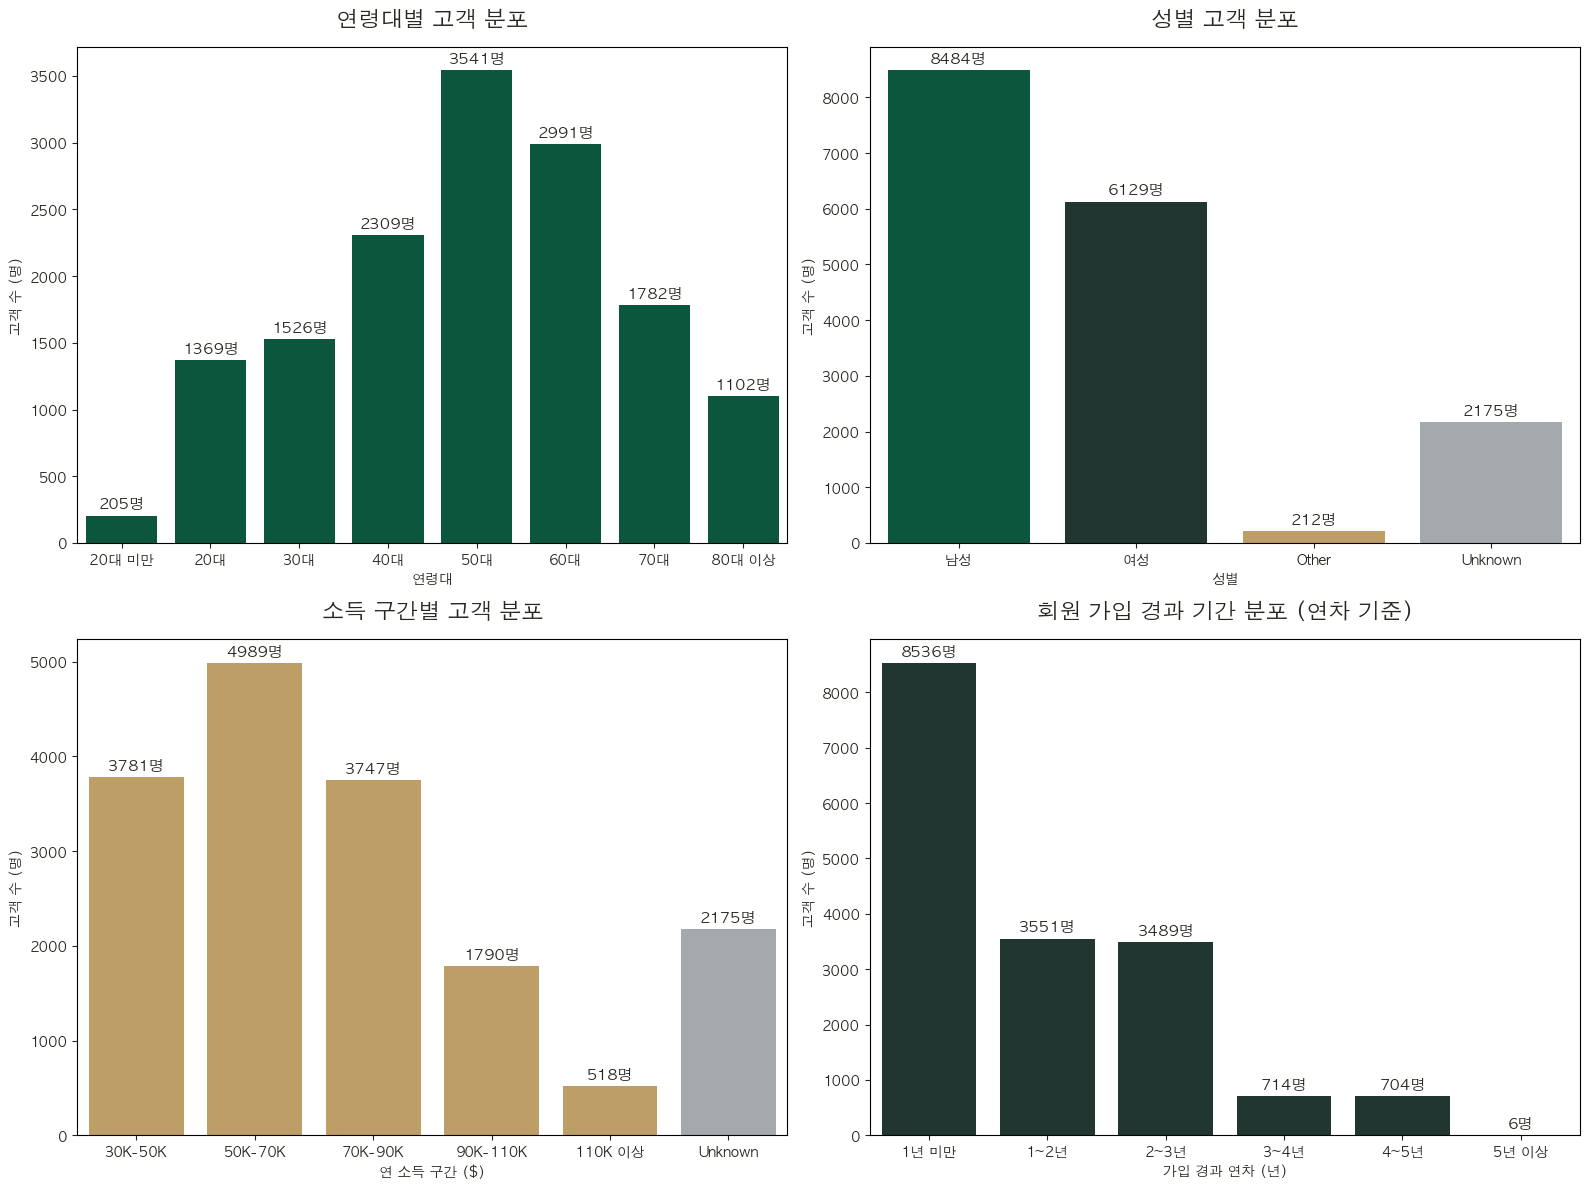

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 연령대별 고객 분포
ax1 = sns.countplot(data=customers, x='age_group', color=SB_GREEN,
                    ax=axes[0, 0], order=AGE_LABELS)
axes[0, 0].set_title('연령대별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('연령대')
axes[0, 0].set_ylabel('고객 수 (명)')
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 성별 고객 분포
ax2 = sns.countplot(data=customers, x='gender_mapped',
                    palette=[SB_GREEN, SB_DEEP_GREEN, SB_GOLD, SB_GREY],
                    ax=axes[0, 1], order=GENDER_ORDER)
axes[0, 1].set_title('성별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('성별')
axes[0, 1].set_ylabel('고객 수 (명)')
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 소득 구간별 고객 분포
ax3 = sns.countplot(data=customers, x='income_group',
                    palette=[SB_GOLD] * 5 + [SB_GREY],
                    ax=axes[1, 0], order=INCOME_ORDER)
axes[1, 0].set_title('소득 구간별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('연 소득 구간 ($)')
axes[1, 0].set_ylabel('고객 수 (명)')
for c in ax3.containers:
    ax3.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 회원 가입 경과 기간 분포
ax4 = sns.countplot(data=customers, x='tenure_group', color=SB_DEEP_GREEN,
                    ax=axes[1, 1], order=TENURE_ORDER)
axes[1, 1].set_title('회원 가입 경과 기간 분포 (연차 기준)', fontsize=16, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('가입 경과 연차 (년)')
axes[1, 1].set_ylabel('고객 수 (명)')
for c in ax4.containers:
    ax4.bar_label(c, fmt='%d명', padding=3, fontsize=11)

plt.tight_layout()
plt.show()


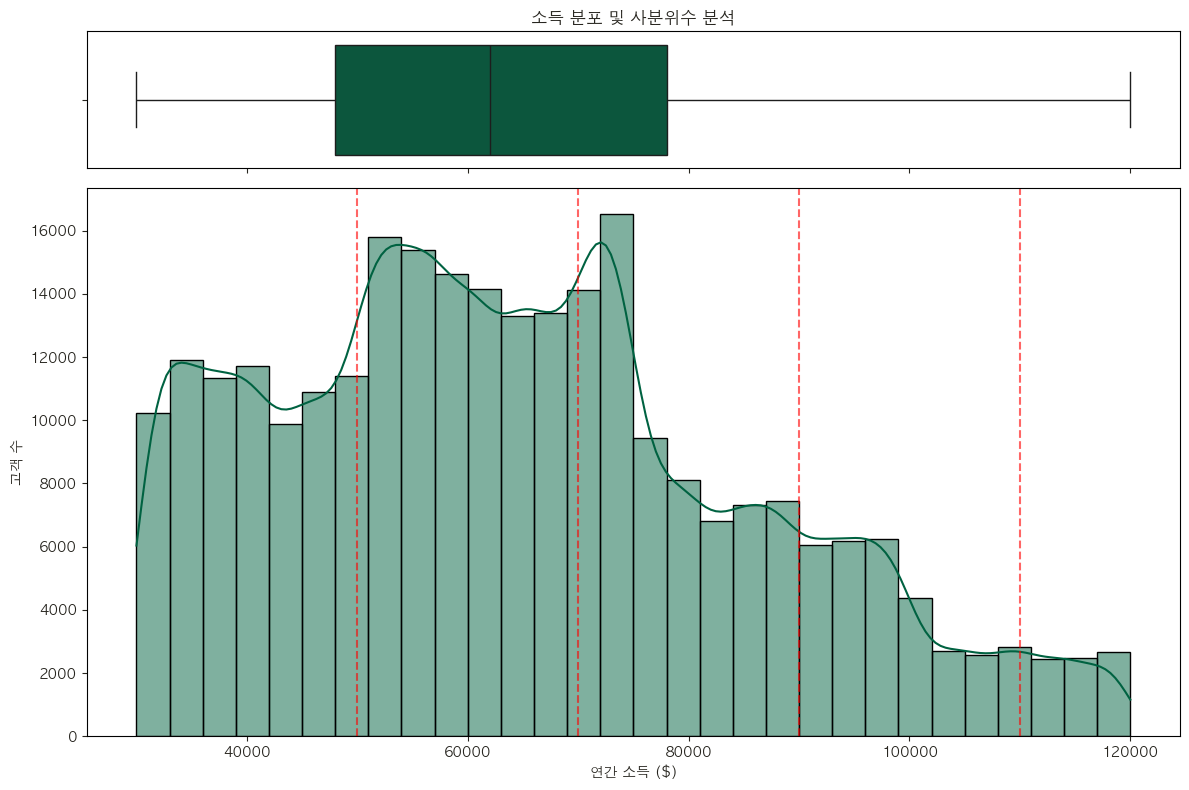

In [9]:
fig, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(12, 8)
)

sns.boxplot(x=df['income'].dropna(), ax=ax_box, color=SB_GREEN)
ax_box.set(title='소득 분포 및 사분위수 분석', xlabel='')

sns.histplot(df['income'].dropna(), kde=True, ax=ax_hist, color=SB_GREEN, bins=30)
ax_hist.set(xlabel='연간 소득 ($)', ylabel='고객 수')

for x in [50000, 70000, 90000, 110000]:
    ax_hist.axvline(x=x, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### 전체 매출 대비 VIP 기여도 및 성별 그룹 내 VIP 비중

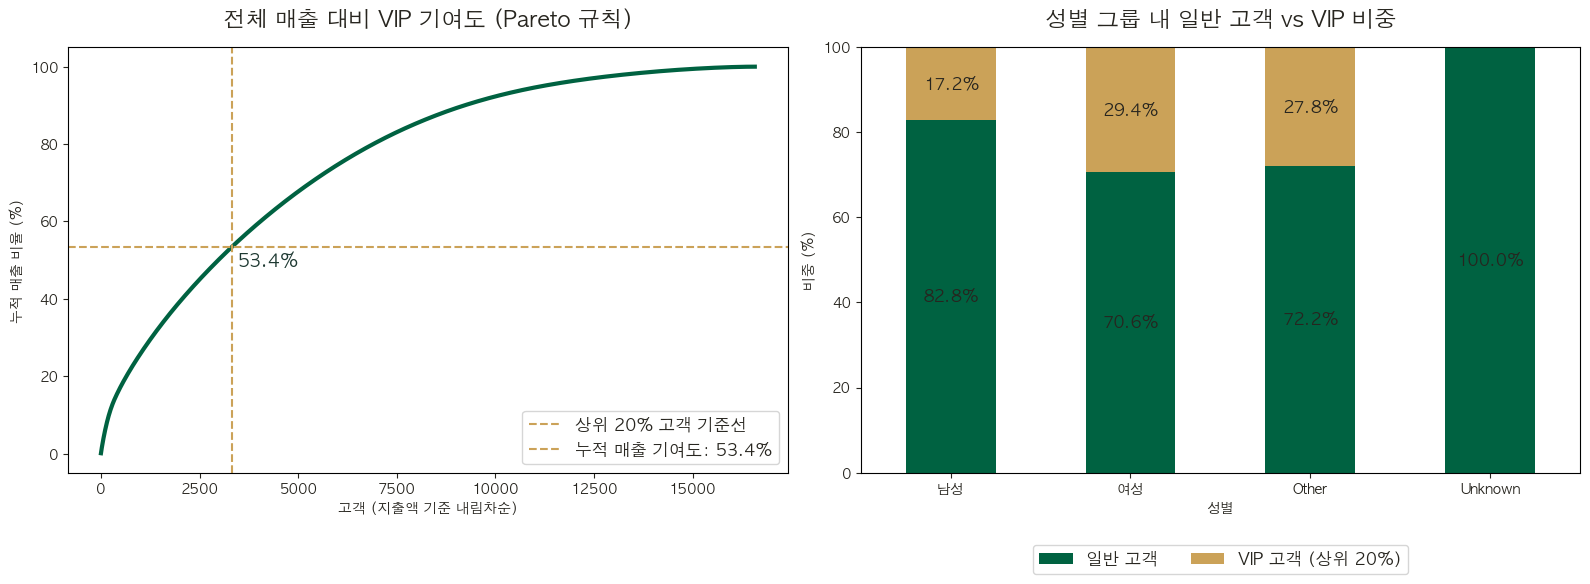

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto 곡선
sorted_cust = (
    customers[customers['total_amount'] > 0]
    .sort_values('total_amount', ascending=False)
    .reset_index(drop=True)
)
sorted_cust['cum_amount']  = sorted_cust['total_amount'].cumsum()
sorted_cust['cum_percent'] = sorted_cust['cum_amount'] / sorted_cust['total_amount'].sum() * 100

top20_idx     = int(len(sorted_cust) * 0.2)
top20_revenue = sorted_cust.loc[top20_idx, 'cum_percent']

axes[0].plot(sorted_cust.index, sorted_cust['cum_percent'], color=SB_GREEN, lw=3)
axes[0].axvline(top20_idx,     color=SB_GOLD, linestyle='--', label='상위 20% 고객 기준선')
axes[0].axhline(top20_revenue, color=SB_GOLD, linestyle='--',
                label=f'누적 매출 기여도: {top20_revenue:.1f}%')
axes[0].set_title('전체 매출 대비 VIP 기여도 (Pareto 규칙)',
                  fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('고객 (지출액 기준 내림차순)')
axes[0].set_ylabel('누적 매출 비율 (%)')
axes[0].text(top20_idx + 150, top20_revenue - 5, f'{top20_revenue:.1f}%',
             color=SB_DEEP_GREEN, fontweight='bold', fontsize=13)
axes[0].legend(fontsize=12)

# 성별 내 VIP 비중
gender_vip = (
    customers.groupby('gender_mapped')['is_vip']
    .value_counts(normalize=True)
    .unstack()
    .reindex(GENDER_ORDER) * 100
)
ax = gender_vip.plot(kind='bar', stacked=True, color=[SB_GREEN, SB_GOLD], ax=axes[1])
axes[1].set_title('성별 그룹 내 일반 고객 vs VIP 비중',
                  fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('성별')
axes[1].set_ylabel('비중 (%)')
axes[1].legend(['일반 고객', 'VIP 고객 (상위 20%)'],
               loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

##### 지출액 기준 상위 20%의 고객이 전체 매출의 53.4%를 발생시키고 있음
##### 고객수는 남성이 더 많지만 VIP 고객 비율은 여성이 높다
##### 이는 고액 지출로 이어지는 충성 고객층은 주로 여성 중심으로 형성되어 있음

##### 여성 VIP 고객의 이탈을 막기 위해, 이들의 선호도와 구매 패턴에 맞춘 프라이빗 혜택이나 전용 맴버십 프로그램을 강화하는 것이 효율적
##### 남성 고객의 VIP 전환 전략 검토 : 전환율이 낮은 이유를 파악해야 한다. 상품군이 부족한 것인지, 마케팅 메시지가 맞지 않는 것인지 분석해야 객단가를 높히는 전략을 마련할 수 있음
##### 전체 매출의 46.6%를 차지하는 일반 고객층 중, 상위 20% 커트라인에 근접한 고객들을 타겟화하여 추가 구매를 유도하면 전체 매출 볼륨을 크게 키울 수 있음.

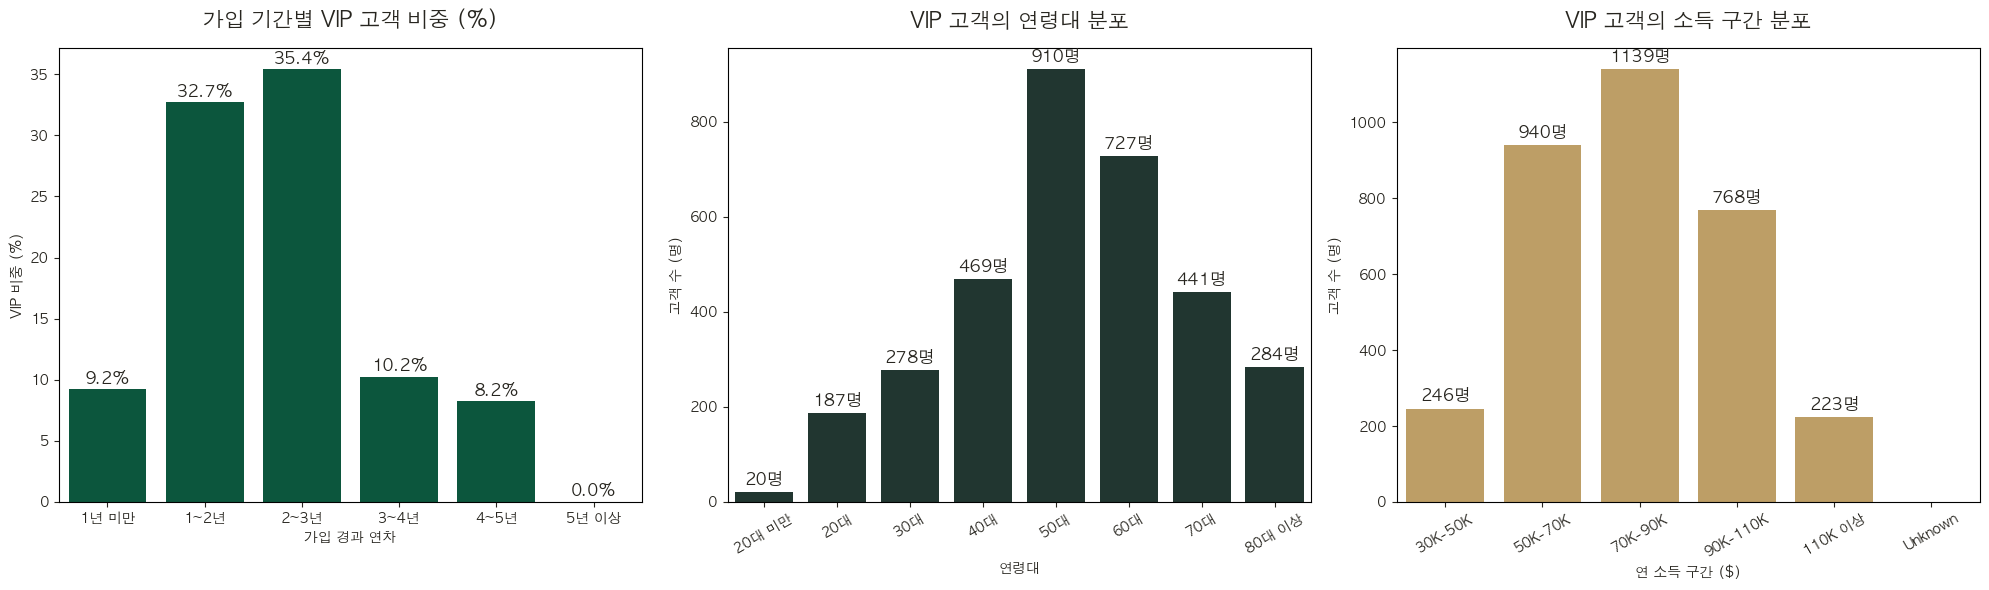

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
vip_cust = customers[customers['is_vip']]

# 가입 기간별 VIP 비중
vip_tenure = customers.groupby('tenure_group')['is_vip'].mean().reindex(TENURE_ORDER) * 100
ax1 = sns.barplot(x=vip_tenure.index, y=vip_tenure.values, color=SB_GREEN, ax=axes[0])
axes[0].set_title('가입 기간별 VIP 고객 비중 (%)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('가입 경과 연차')
axes[0].set_ylabel('VIP 비중 (%)')
for i, v in enumerate(vip_tenure.values):
    if not pd.isna(v):
        ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# VIP 고객의 연령대 분포
ax2 = sns.countplot(data=vip_cust, x='age_group', color=SB_DEEP_GREEN,
                    ax=axes[1], order=AGE_LABELS)
axes[1].set_title('VIP 고객의 연령대 분포', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('연령대')
axes[1].set_ylabel('고객 수 (명)')
axes[1].tick_params(axis='x', rotation=30)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=12)

# VIP 고객의 소득 구간 분포
ax3 = sns.countplot(data=vip_cust, x='income_group', color=SB_GOLD,
                    ax=axes[2], order=INCOME_ORDER)
axes[2].set_title('VIP 고객의 소득 구간 분포', fontsize=15, fontweight='bold', pad=15)
axes[2].set_xlabel('연 소득 구간 ($)')
axes[2].set_ylabel('고객 수 (명)')
axes[2].tick_params(axis='x', rotation=30)
for c in ax3.containers:
    ax3.bar_label(c, fmt='%d명', padding=3, fontsize=12)

plt.tight_layout()
plt.show()


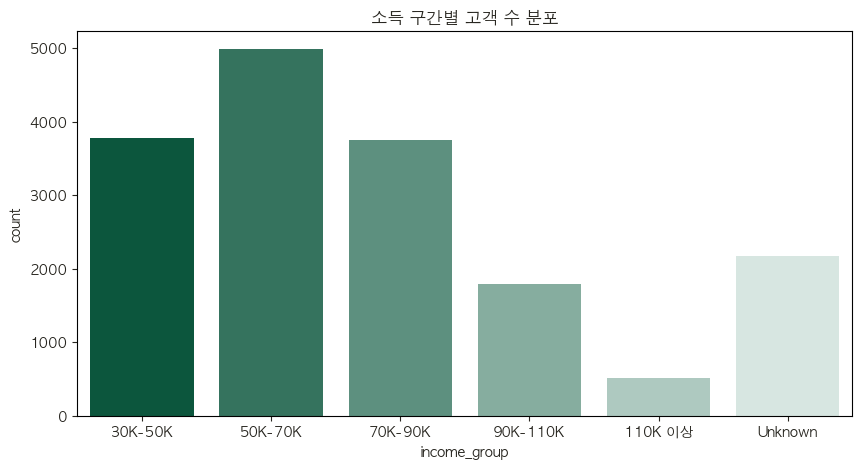

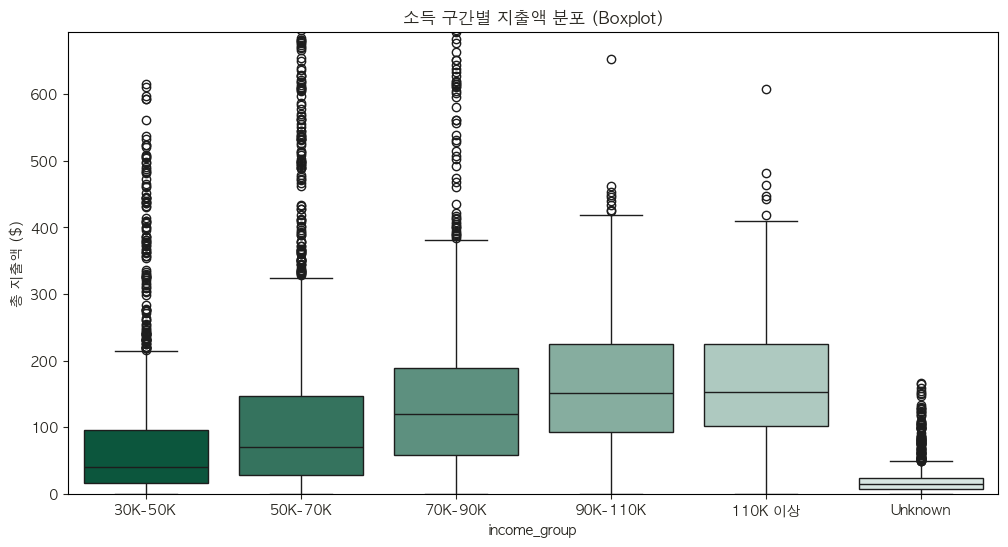

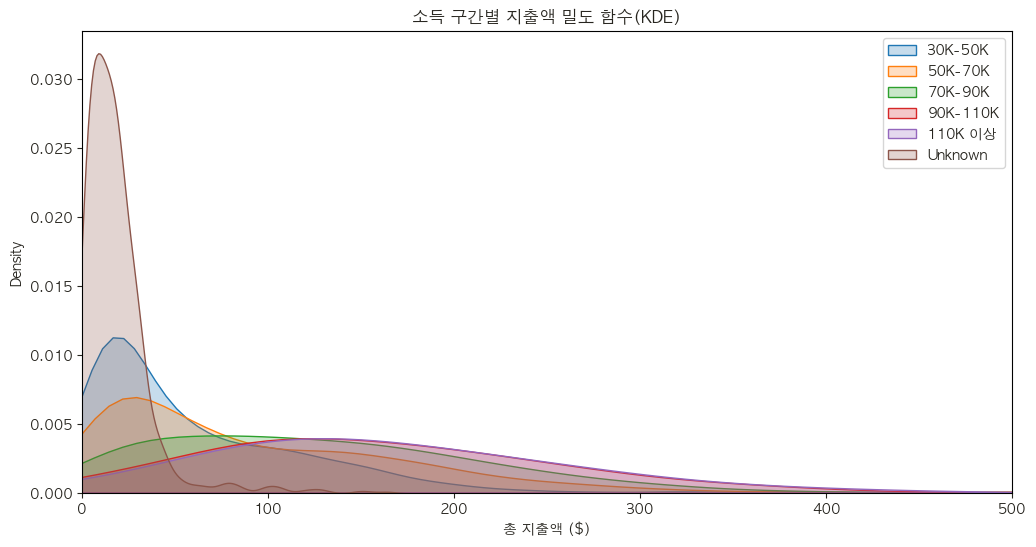

[소득 구간별 지출액 차이 — Kruskal-Wallis]
  H = 2327.12,  p = 0.0000  ★ 유의미 (p<0.05)
  → 소득 구간 간 지출액 분포에 유의미한 차이가 있습니다.
    (사후 검정 필요: 아래 셀 참고)


In [12]:
income_group_palette = sns.blend_palette([SB_GREEN, SB_LIGHT_GREEN], n_colors=6)

# 1. 소득 구간별 고객 수 분포 (샘플 사이즈 확인)
plt.figure(figsize=(10, 5))
sns.countplot(data=customers, x='income_group', order=INCOME_ORDER, palette=income_group_palette)
plt.title('소득 구간별 고객 수 분포')
plt.show()

# 2. 소득 구간별 지출액(total_amount) 분포 - Boxplot
# 지출액의 편차가 크므로 y축 범위를 조정하거나 로그 스케일을 고려할 수 있습니다.
plt.figure(figsize=(12, 6))
sns.boxplot(data=customers, x='income_group', y='total_amount', order=INCOME_ORDER, palette=income_group_palette)
plt.title('소득 구간별 지출액 분포 (Boxplot)')
plt.ylim(0, customers['total_amount'].quantile(0.99)) # 상위 1% 제외하고 시각화 (이상치 영향 감소)
plt.ylabel('총 지출액 ($)')
plt.show()

# 3. 소득 구간별 지출액 밀도 그래프 (Distribution Shape 확인)
plt.figure(figsize=(12, 6))
for grp in INCOME_ORDER:
    subset = customers[customers['income_group'] == grp]
    sns.kdeplot(subset['total_amount'], label=grp, fill=True)

plt.title('소득 구간별 지출액 밀도 함수(KDE)')
plt.xlim(0, 500) # 주요 지출 구간 집중 확인
plt.xlabel('총 지출액 ($)')
plt.legend()
plt.show()

# 소득 구간별 지출액 Kruskal-Wallis 검정
income_groups = [
    customers[customers['income_group'] == grp]['total_amount'].dropna()
    for grp in INCOME_LABELS
    if len(customers[customers['income_group'] == grp]) > 0
]
k_stat, k_p = kruskal(*income_groups)
print("=" * 60)
print("[소득 구간별 지출액 차이 — Kruskal-Wallis]")
print(f"  H = {k_stat:.2f},  p = {k_p:.4f}  {'★ 유의미 (p<0.05)' if k_p < 0.05 else '유의미하지 않음'}")
if k_p < 0.05:
    print("  → 소득 구간 간 지출액 분포에 유의미한 차이가 있습니다.")
    print("    (사후 검정 필요: 아래 셀 참고)")
print("=" * 60)


##### 중/저소득층 (30K-90K): 트래픽을 유발하는 다수이므로, 'BOGO(1+1)'나 '할인 쿠폰'처럼 가격 민감도를 낮춰주는 혜택이 효과적일 수 있다.

##### 고소득층 (90K 이상): 가격보다는 가치에 반응할 가능성이 높으므로, 가격 할인이 없더라도 특별한 경험을 제공하는 프로모션(예: 신메뉴 선공개, 일정 금액 이상 구매 시 한정판 굿즈 증정 등)이 객단가를 극대화하는 데 유리.

##### Unknown 그룹 정비: 이 그룹에 마케팅 예산을 낭비하지 않도록 타겟팅에서 제외하거나, 첫 구매를 유도하는 강력한 웰컴 쿠폰 하나만을 찔러보는 식별화 작업이 필요해 보인다.

[소득 구간별 지출액 사후 검정 — Dunn's Test (Bonferroni)]


,30K-50K,50K-70K,70K-90K,90K-110K,110K 이상,Unknown
30K-50K,1.000000e+00,1.663061e-71,1.107966e-250,1.154642e-301,3.723689e-127,2.395775e-169
50K-70K,1.663061e-71,1.000000e+00,1.602102e-72,1.080713e-132,1.048938e-56,0.000000e+00
70K-90K,1.107966e-250,1.602102e-72,1.000000e+00,3.866351e-22,1.778261e-12,0.000000e+00
90K-110K,1.154642e-301,1.080713e-132,3.866351e-22,1.000000e+00,1.000000e+00,0.000000e+00
110K 이상,3.723689e-127,1.048938e-56,1.778261e-12,1.000000e+00,1.000000e+00,0.000000e+00
Unknown,2.395775e-169,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


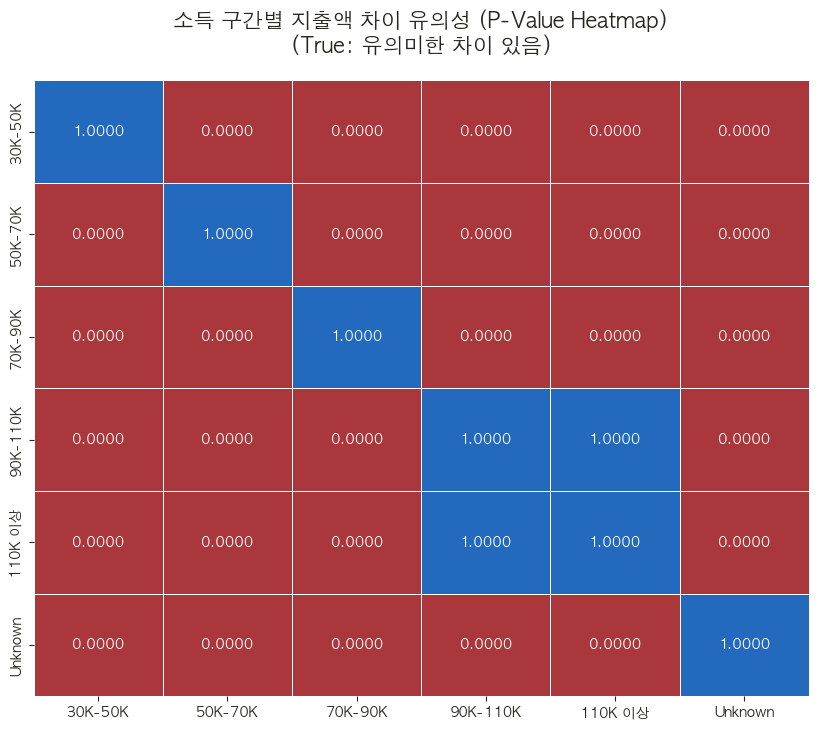

In [13]:
import scikit_posthocs as sp

# 사후 검정 (Dunn's test) 수행
# 보정 방법으로 'bonferroni' 또는 'holm'을 주로 사용합니다.
posthoc_df = sp.posthoc_dunn(
    customers, 
    val_col='total_amount', 
    group_col='income_group', 
    p_adjust='bonferroni'
)

# 결과 출력 (0.05보다 작은 값들이 유의미한 차이가 있는 쌍입니다)
print("=" * 60)
print("[소득 구간별 지출액 사후 검정 — Dunn's Test (Bonferroni)]")
display(posthoc_df)
print("=" * 60)

# 시각화 (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    posthoc_df < 0.05, 
    annot=posthoc_df,
    fmt=".4f", 
    cmap='vlag', 
    cbar=False,
    linewidths=.5
)
plt.title('소득 구간별 지출액 차이 유의성 (P-Value Heatmap)\n(True: 유의미한 차이 있음)', 
          fontsize=15, fontweight='bold', pad=20)
plt.show()

### 소득 구간별 지출액 통계 검정 결과 정리
#### [분석 목적]
##### 고객의 연간 소득 수준이 총 지출액 형성에 유의미한 영향을 미치는지 검증하고, 마케팅 타겟팅을 위한 소득 구간별 구매력 차이를 확인하고자 함.

#### [검정 방법]
##### 1. 그룹 간 차이 검정 - Kruskal-wallis Test : 데이터의 비정규성 고려
##### 결과 : H = 2327.12, p < 0.001 (굉장히 유의미)
##### 해석 : 모든 소득 구간의 지출액 분포가 동일하다는 귀무가설을 기각함. 즉, 소득 구간에 따라 지출액의 차이가 매우 확실하게 존재함.

##### 2. 상세 구간 비교 - Dunn's Post-hoc Test
##### 결과 : 최상위 고소득층 두 그룹(90K-110K와 110K 이상) 간을 제외한 모든 소득 구간에서 서로 유의미한 지출액 차이(p < 0.001)를 보임
##### 해석 : 단순히 "차이가 있다"를 넘어, 모든 소득 구간이 서로 통계적으로 다른 지출 패턴을 보임.

#### [최종 인사이트]
##### 돈을 많이 벌면 많이 쓴다는 직관이 본 데이터셋에서 높은 신뢰도로 증명.
##### 모든 구간이 통계적으로 다르기 때문에, 각 소득 구간별로 차별화된 오퍼를 제공하는 전략이 데이터적으로 정당성을 가짐.
##### 소득 미기재 그룹(Unknown) 또한 다른 모든 그룹과 유의미하게 다른 지출 패턴을 보이므로, 이들을 별도의 마케팅 관리 대상으로 분류할 필요가 있음.

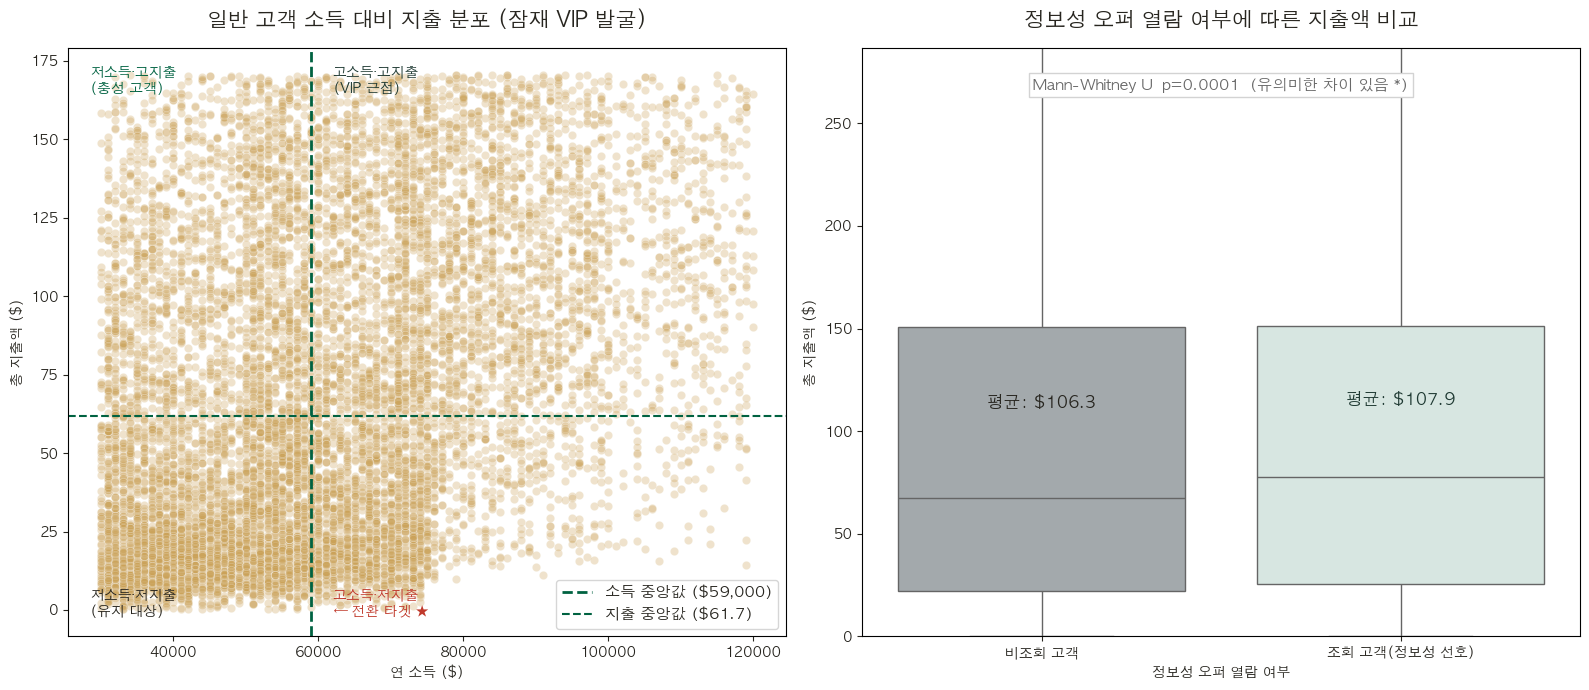

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 일반 고객 소득 대비 지출 분포 (잠재 VIP 발굴)
general_cust = customers[~customers['is_vip'] & (customers['total_amount'] > 0) & customers['income'].notna()].copy()

sns.scatterplot(data=general_cust, x='income', y='total_amount',
                alpha=0.3, color=SB_GOLD, ax=axes[0])

med_inc = general_cust['income'].median()
med_amt = general_cust['total_amount'].median()

axes[0].axvline(med_inc, color=SB_GREEN, linestyle='--', lw=2,
                label=f'소득 중앙값 (${med_inc:,.0f})')
axes[0].axhline(med_amt, color=SB_GREEN, linestyle='--', lw=1.5,
                label=f'지출 중앙값 (${med_amt:.1f})')
axes[0].set_title('일반 고객 소득 대비 지출 분포 (잠재 VIP 발굴)',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('연 소득 ($)')
axes[0].set_ylabel('총 지출액 ($)')
axes[0].legend(fontsize=11)

xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()
x_offset = (xlim[1] - xlim[0]) * 0.03
y_offset = (ylim[1] - ylim[0]) * 0.03

axes[0].text(med_inc + x_offset, ylim[1] - y_offset,
             '고소득·고지출\n(VIP 근접)',      ha='left', va='top',   fontsize=10, color=SB_DEEP_GREEN, fontweight='bold')
axes[0].text(med_inc + x_offset, ylim[0] + y_offset,
             '고소득·저지출\n← 전환 타겟 ★', ha='left', va='bottom', fontsize=10, color='#C0392B',    fontweight='bold')
axes[0].text(xlim[0] + x_offset, ylim[1] - y_offset,
             '저소득·고지출\n(충성 고객)',      ha='left', va='top',   fontsize=10, color=SB_GREEN)
axes[0].text(xlim[0] + x_offset, ylim[0] + y_offset,
             '저소득·저지출\n(유지 대상)',      ha='left', va='bottom', fontsize=10, color=SB_BLACK)

# 정보성 오퍼 열람 여부별 지출액 비교 (박스플롯)
sns.boxplot(data=customers[customers['total_amount'] > 0],
            x='info_viewer', y='total_amount',
            palette=[SB_GREY, SB_LIGHT_GREEN], ax=axes[1])

axes[1].set_title('정보성 오퍼 열람 여부에 따른 지출액 비교',
                  fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(['비조회 고객', '조회 고객(정보성 선호)'])
axes[1].set_xlabel('정보성 오퍼 열람 여부')
axes[1].set_ylabel('총 지출액 ($)')

axes[1].set_ylim(0, customers['total_amount'].quantile(0.95))

mean_non = customers[(customers['total_amount'] > 0) & ~customers['info_viewer']]['total_amount'].mean()
mean_yes = customers[(customers['total_amount'] > 0) &  customers['info_viewer']]['total_amount'].mean()
axes[1].text(0, mean_non + 5, f'평균: ${mean_non:.1f}', ha='center',
             fontweight='bold', color=SB_BLACK,      fontsize=12)
axes[1].text(1, mean_yes + 5, f'평균: ${mean_yes:.1f}', ha='center',
             fontweight='bold', color=SB_DEEP_GREEN, fontsize=12)

# Mann-Whitney U 검정 수행 및 텍스트 표시
from scipy.stats import mannwhitneyu
g1 = customers[(customers['total_amount'] > 0) & ~customers['info_viewer']]['total_amount']
g2 = customers[(customers['total_amount'] > 0) &  customers['info_viewer']]['total_amount']
stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
sig = "유의미한 차이 있음 *" if p_val < 0.05 else "유의미한 차이 없음"

axes[1].text(0.5, axes[1].get_ylim()[1] * 0.95,
             f'Mann-Whitney U  p={p_val:.4f}  ({sig})',
             ha='center', va='top', fontsize=11, color='dimgray',
             transform=axes[1].transData,
             bbox=dict(fc='white', ec='lightgray', pad=3))

plt.tight_layout()
plt.show()

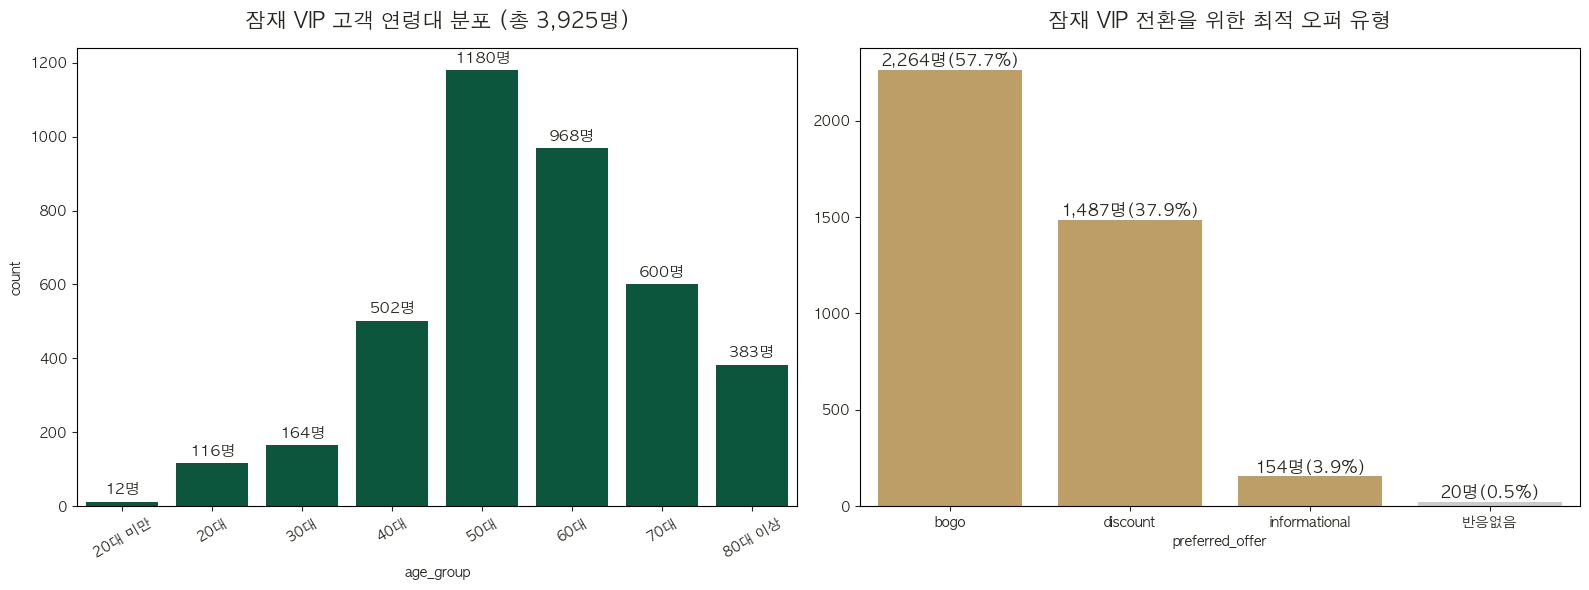

In [15]:
potential_vip_mask = (~customers['is_vip']) & (customers['income'] >= 70000)
potential_vips     = customers[potential_vip_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 잠재 VIP 연령대 분포
ax1 = sns.countplot(data=potential_vips, x='age_group', color=SB_GREEN,
                    order=AGE_LABELS, ax=axes[0])
axes[0].set_title(f'잠재 VIP 고객 연령대 분포 (총 {len(potential_vips):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=30)
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 잠재 VIP 선호 오퍼
pref_offer = potential_vips['preferred_offer'].value_counts()
ax2 = sns.barplot(x=pref_offer.index, y=pref_offer.values,
                  palette=[SB_GOLD] * 3 + ['#CCCCCC'], ax=axes[1])
axes[1].set_title('잠재 VIP 전환을 위한 최적 오퍼 유형',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(pref_offer.values):
    ax2.text(i, v + 20, f'{v:,.0f}명({v/len(potential_vips)*100:.1f}%)',
             ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

##### 5060 고소득저지출 즉, 우리 브랜드에 지갑을 열지 않은 그룹이 뚜렷하게 존재 - > 구매를 유인할 결정적인 트리거가 없었을 확률이 큼 -> bogo쿠폰을 우선순위 오퍼로 진행 후 discount오퍼 진행

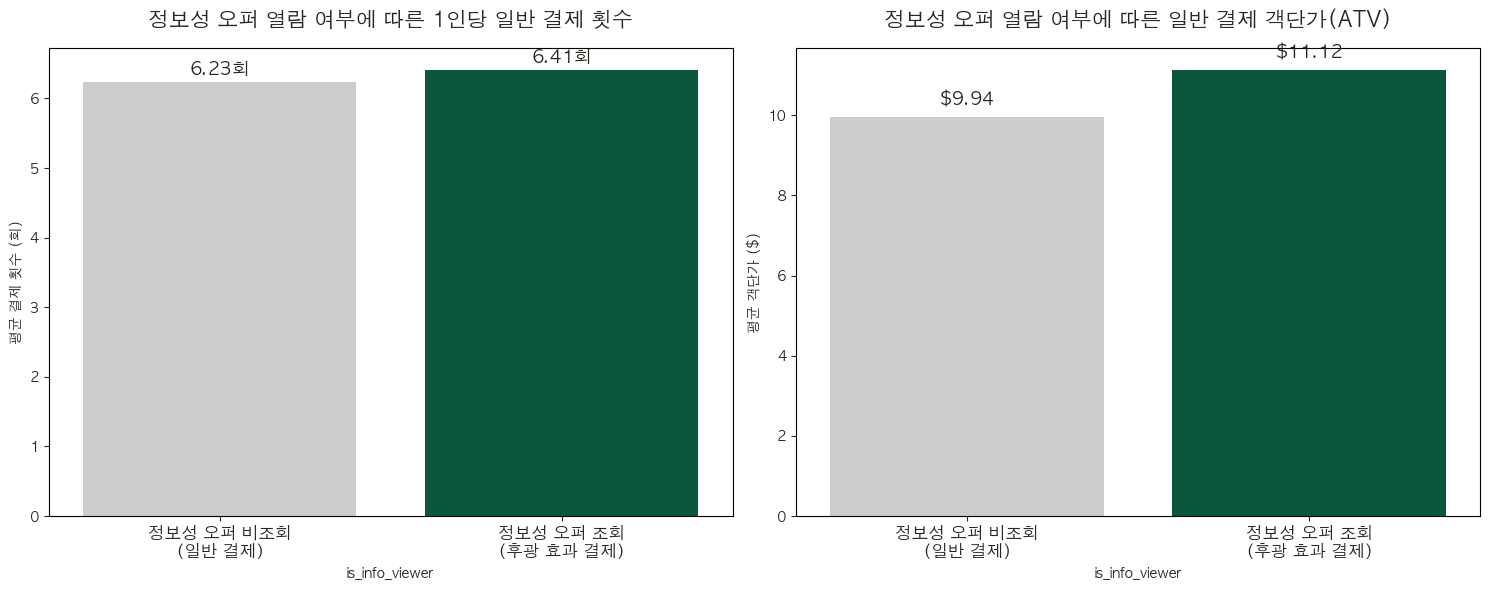

[후광 효과 통계 검정 — Mann-Whitney U]
결제 횟수 차이  : p = 0.0002  ★ 유의미 (p<0.05)
객단가 차이     : p = 0.0000  ★ 유의미 (p<0.05)

정보성 오퍼 조회 고객이 일반 결제 횟수 약 2.8% 더 많음
단, 선택 편향(원래 고관여 고객) 가능성을 배제할 수 없으므로
'열람이 구매를 유발한다'는 인과 주장은 신중하게 해석해야 합니다.


In [16]:
# 일반 결제(오퍼 X) 추출
tx_df   = df[df['event'] == 'transaction'][['customer_id','time_days','amount']]
comp_df = df[df['event'] == 'completed'  ][['customer_id','time_days','offer_type']]

tx_merged = pd.merge(tx_df, comp_df, on=['customer_id','time_days'], how='left')
tx_merged = tx_merged.drop_duplicates(subset=['customer_id','time_days','amount'])

general_tx = tx_merged[tx_merged['offer_type'].isna()].copy()
general_tx['is_info_viewer'] = general_tx['customer_id'].isin(info_viewers)

# 그룹별 집계
freq_df  = general_tx.groupby(['is_info_viewer','customer_id']).size().reset_index(name='tx_count')
avg_freq = freq_df.groupby('is_info_viewer')['tx_count'].mean()
avg_atv  = general_tx.groupby('is_info_viewer')['amount'].mean()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
labels = ['정보성 오퍼 비조회\n(일반 결제)', '정보성 오퍼 조회\n(후광 효과 결제)']
colors = ['#CCCCCC', SB_GREEN]

ax1 = sns.barplot(x=avg_freq.index, y=avg_freq.values, palette=colors, ax=axes[0])
axes[0].set_title('정보성 오퍼 열람 여부에 따른 1인당 일반 결제 횟수',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_ylabel('평균 결제 횟수 (회)')
for i, v in enumerate(avg_freq.values):
    ax1.text(i, v + 0.1, f'{v:.2f}회', ha='center', fontweight='bold', fontsize=13)

ax2 = sns.barplot(x=avg_atv.index, y=avg_atv.values, palette=colors, ax=axes[1])
axes[1].set_title('정보성 오퍼 열람 여부에 따른 일반 결제 객단가(ATV)',
                  fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylabel('평균 객단가 ($)')
for i, v in enumerate(avg_atv.values):
    ax2.text(i, v + 0.3, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# ── Mann-Whitney U 검정 (결제 횟수 & 객단가) ──
g_no  = freq_df[~freq_df['is_info_viewer']]['tx_count']
g_yes = freq_df[ freq_df['is_info_viewer']]['tx_count']
stat_freq, p_freq = mannwhitneyu(g_no, g_yes, alternative='two-sided')

g_no_atv  = general_tx[~general_tx['is_info_viewer']]['amount']
g_yes_atv = general_tx[general_tx['is_info_viewer']]['amount']
stat_atv,  p_atv  = mannwhitneyu(g_no_atv, g_yes_atv, alternative='two-sided')

print("=" * 70)
print("[후광 효과 통계 검정 — Mann-Whitney U]")
print(f"결제 횟수 차이  : p = {p_freq:.4f}  {'★ 유의미 (p<0.05)' if p_freq < 0.05 else '유의미하지 않음'}")
print(f"객단가 차이     : p = {p_atv:.4f}  {'★ 유의미 (p<0.05)' if p_atv  < 0.05 else '유의미하지 않음'}")
print()
if avg_freq[True] > avg_freq[False]:
    print(f"정보성 오퍼 조회 고객이 일반 결제 횟수 약 {(avg_freq[True]/avg_freq[False]-1)*100:.1f}% 더 많음")
    print("단, 선택 편향(원래 고관여 고객) 가능성을 배제할 수 없으므로")
    print("'열람이 구매를 유발한다'는 인과 주장은 신중하게 해석해야 합니다.")
print("=" * 70)


##### 이 분석은 상관관계임. 고관여 고객이 원래부터 열람률이 높을 수 있으므로(선택 편향), 인과 관계로 단정하지 말 것.

##### 결과 : 결제 횟수($p=0.0002$), 객단가($p=0.0000$) 모두 유의미.
##### 해석 : 정보성 오퍼는 직접적인 보상이 없어도 브랜드 상기 효과를 통해 고객을 매장으로 불러들이고(횟수 증가), 더 많이 쓰게(객단가 증가) 만드는 후광 효과가 입증됨.
##### 전략 : VIP와 고소득층에게는 비용이 드는 할인 쿠폰보다 정보성 콘텐츠를 자주 노출하는 것이 비용 효율적임을 시사.

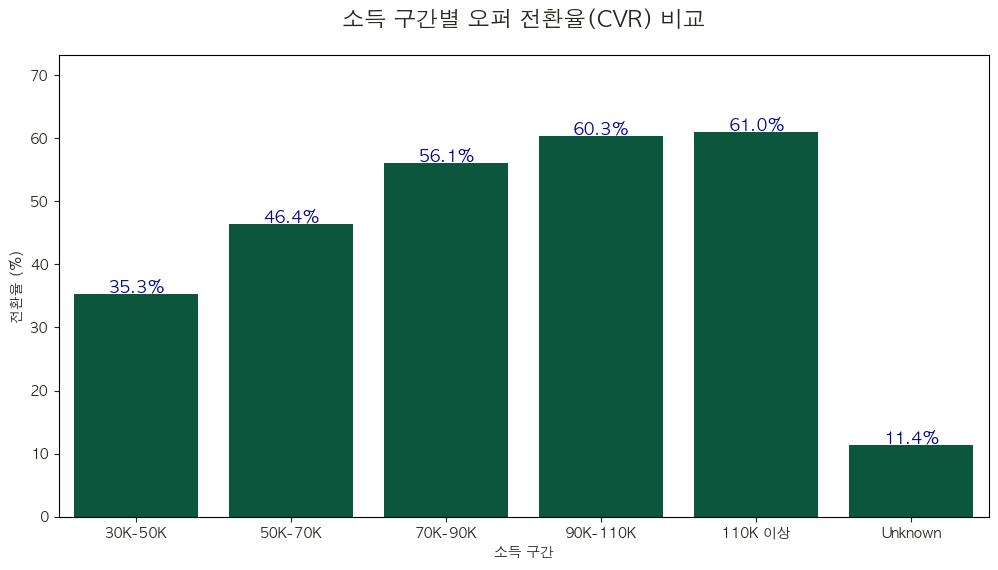

In [17]:
# 오퍼 반응 데이터 계산 (Received -> Completed 전환율)
offer_stats = df[df['event'].isin(['received', 'completed'])].copy()

# 소득 구간 정보 결합
offer_stats = pd.merge(offer_stats, customers[['customer_id', 'income_group']], on='customer_id', how='left')

# 구간별/이벤트별 카운트
cvr_data = offer_stats.groupby(['income_group', 'event']).size().unstack(fill_value=0)
cvr_data['conversion_rate'] = (cvr_data['completed'] / cvr_data['received']) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=cvr_data.index, y=cvr_data['conversion_rate'], palette=[SB_GREEN], order=INCOME_ORDER)

plt.title('소득 구간별 오퍼 전환율(CVR) 비교', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('전환율 (%)')
plt.xlabel('소득 구간')
plt.ylim(0, cvr_data['conversion_rate'].max() * 1.2)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', fontsize=12, fontweight='bold', color='darkblue')

plt.show()

##### 30K-50K(54.0%)에서 시작해 소득이 높아질수록 전환율이 가파르게 상승하여, 110K 이상 구간에서는 82.2%라는 압도적인 반응률을 보임

#### [마케팅 반응 최종 통계 및 인사이트]
##### 고소득층은 구매력(Buying Power)과 반응도(Response)를 모두 갖춘 최적의 타겟.
##### 고소득 VIP 세그먼트에게는 '정보성 오퍼'로 브랜드 로열티를 관리하고, '전략적 오퍼'로 확실한 매출을 견인하는 투트랙 전략이 유효함.

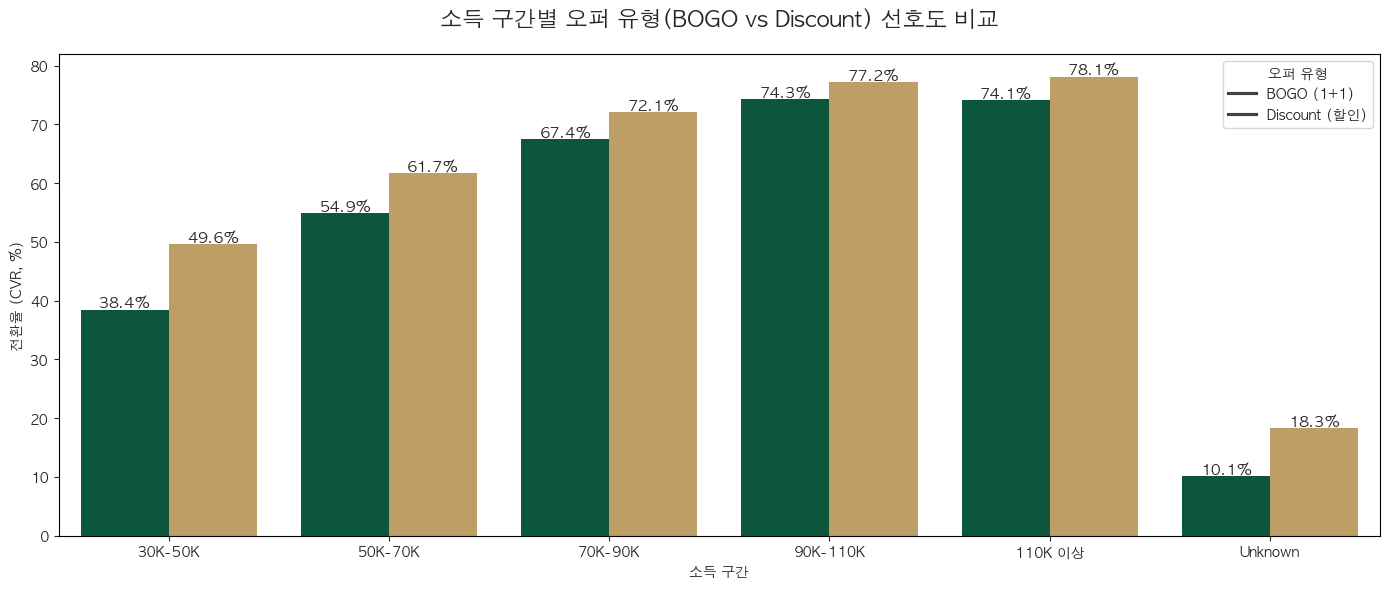

In [18]:
# 오퍼 유형별 전환율 데이터
offer_type_stats = df[df['event'].isin(['received', 'completed'])].copy()
offer_type_stats = pd.merge(offer_type_stats, customers[['customer_id', 'income_group']], on='customer_id', how='left')

# 유형별(BOGO/Discount)로 나누어 계산
offer_pivot = offer_type_stats.groupby(['income_group', 'offer_type', 'event']).size().unstack(fill_value=0)
offer_pivot['cvr'] = (offer_pivot['completed'] / offer_pivot['received']) * 100
offer_pivot = offer_pivot.reset_index()

# 시각화
plt.figure(figsize=(14, 6))
sns.barplot(data=offer_pivot[offer_pivot['offer_type'].isin(['bogo', 'discount'])], 
            x='income_group', y='cvr', hue='offer_type', 
            palette=[SB_GREEN, SB_GOLD], order=INCOME_ORDER)

plt.title('소득 구간별 오퍼 유형(BOGO vs Discount) 선호도 비교', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('전환율 (CVR, %)')
plt.xlabel('소득 구간')
plt.legend(title='오퍼 유형', labels=['BOGO (1+1)', 'Discount (할인)'])

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                           ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

##### 소득 구간이 높아질수록 오퍼 전환율이 정비례하여 상승하며 모든 소득 구간에서 할인 오퍼의 전환율(발송대비완료)이 일관되게 더 높음.

##### 각적인 매출(CVR) 전환이 목표라면 '할인(Discount)'을 주력 무기로 사용해야 한다.

### 고객 세그먼트 딥다이브

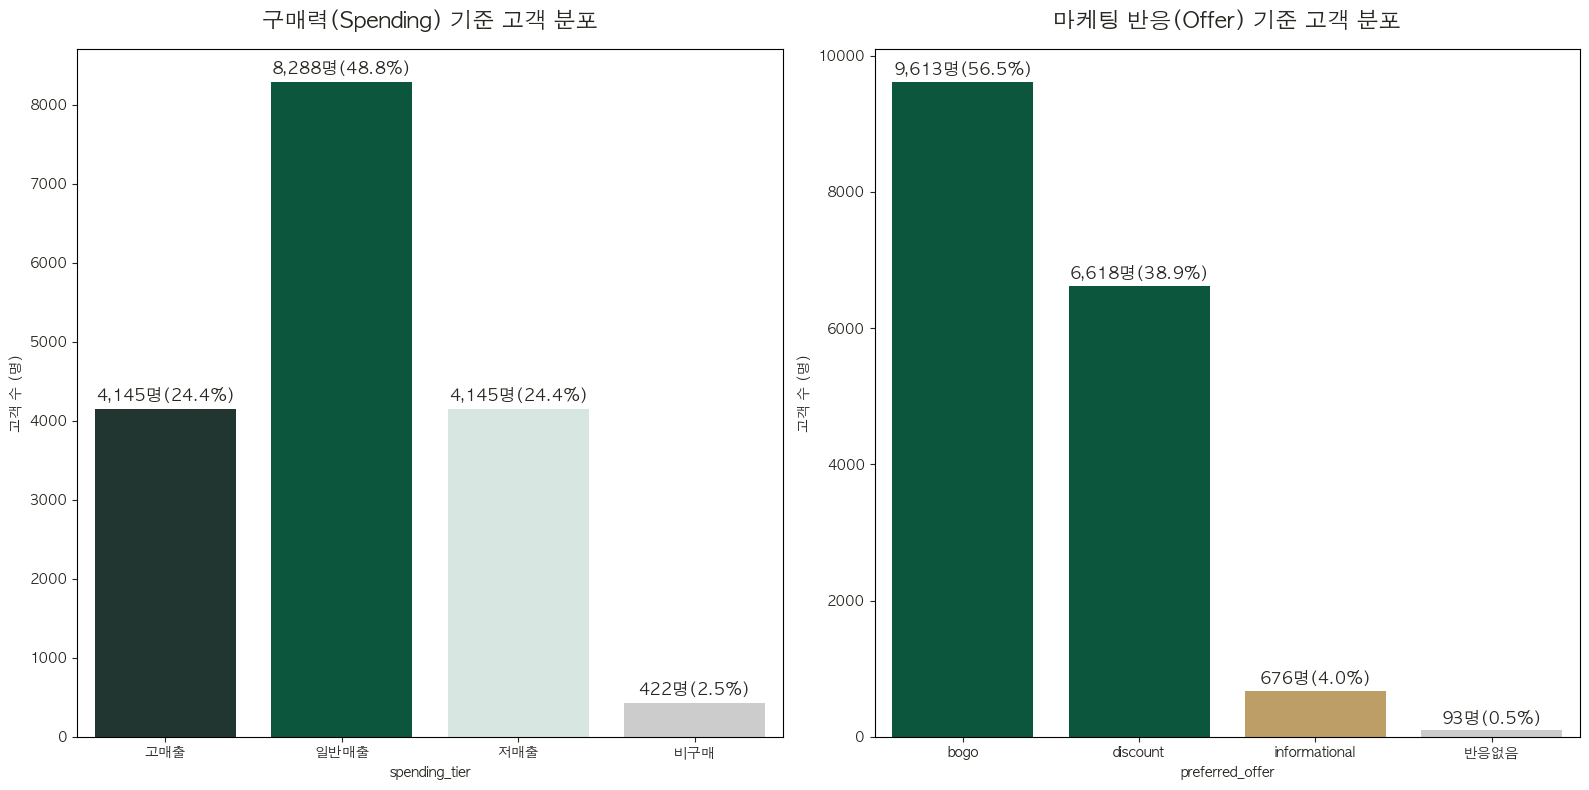

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 구매력 기준 분포
spend_order  = ['고매출', '일반매출', '저매출', '비구매']
spend_counts = customers['spending_tier'].value_counts().reindex(spend_order)
spend_pct    = spend_counts / len(customers) * 100

ax1 = sns.barplot(x=spend_counts.index, y=spend_counts.values,
                  palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, '#CCCCCC'], ax=axes[0])
axes[0].set_title('구매력(Spending) 기준 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('고객 수 (명)')
for i, (v, p) in enumerate(zip(spend_counts.values, spend_pct.values)):
    if not pd.isna(v):
        ax1.text(i, v + 100, f'{v:,.0f}명({p:.1f}%)', ha='center',
                 fontweight='bold', fontsize=12)

# 마케팅 반응 기준 분포
offer_order  = ['bogo', 'discount', 'informational', '반응없음']
offer_counts = customers['preferred_offer'].value_counts().reindex(offer_order)
offer_pct    = offer_counts / len(customers) * 100

ax2 = sns.barplot(x=offer_counts.index, y=offer_counts.values,
                  palette=[SB_GREEN, SB_GREEN, SB_GOLD, '#CCCCCC'], ax=axes[1])
axes[1].set_title('마케팅 반응(Offer) 기준 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('고객 수 (명)')
for i, (v, p) in enumerate(zip(offer_counts.values, offer_pct.values)):
    if not pd.isna(v):
        ax2.text(i, v + 100, f'{v:,.0f}명({p:.1f}%)', ha='center',
                 fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


#### [액션 플랜]
##### bogo 오퍼 유형으로 고소득 일반 고객 타겟 프로모션 진행 후 discount 오퍼 추가 진행 고려

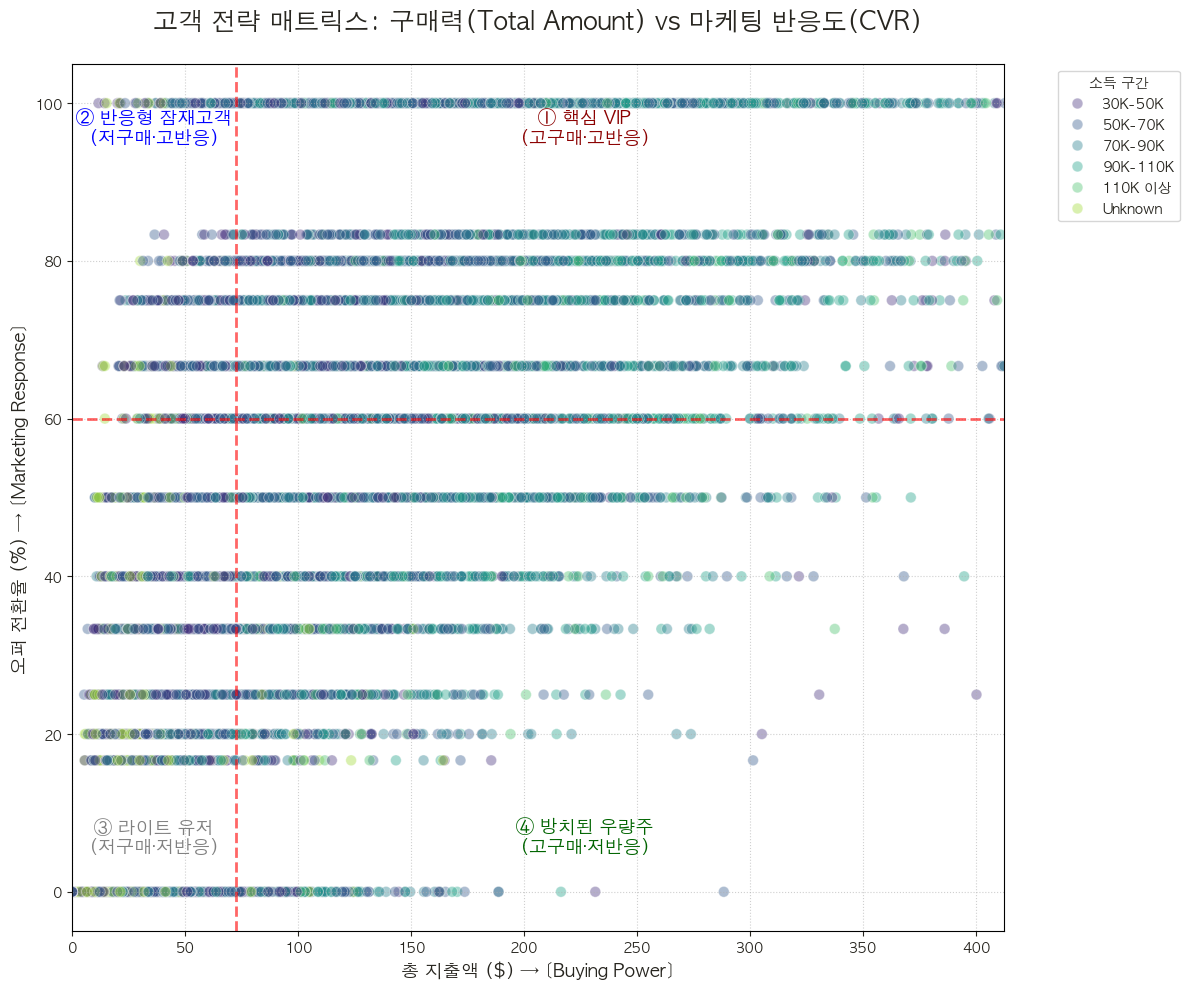

In [20]:
# 고객별 마케팅 반응도(CVR) 계산
offer_counts = df[df['event'].isin(['received', 'completed'])].groupby(['customer_id', 'event']).size().unstack(fill_value=0)

if 'received' in offer_counts.columns and 'completed' in offer_counts.columns:
    # 수령(received)이 0인 경우 결측치 처리를 위해 np.where 사용
    offer_counts['individual_cvr'] = np.where(
        offer_counts['received'] > 0,
        (offer_counts['completed'] / offer_counts['received']) * 100,
        np.nan
    )
else:
    offer_counts['individual_cvr'] = np.nan

# 기존 customers 데이터와 결합
matrix_df = pd.merge(customers, offer_counts[['individual_cvr']], on='customer_id', how='left')

# total_amount도 혹시 모를 결측치가 있다면 개별적으로 처리
matrix_df['total_amount'] = matrix_df['total_amount'].fillna(0)

# 마스터 테이블 추출
matrix_df.to_csv('../../Data/master_customer_matrix_260329.csv', index=False)

# 시각화 (4분면 매트릭스)
plt.figure(figsize=(12, 10))

# 중앙값(Median) 기준 (지출이 있는 고객 대상)
x_mid = matrix_df[matrix_df['total_amount'] > 0]['total_amount'].median()
y_mid = matrix_df[matrix_df['individual_cvr'] > 0]['individual_cvr'].median()

sns.scatterplot(data=matrix_df, x='total_amount', y='individual_cvr', 
                alpha=0.4, hue='income_group', palette='viridis', s=60)

plt.axvline(x_mid, color='red', linestyle='--', alpha=0.6, lw=2)
plt.axhline(y_mid, color='red', linestyle='--', alpha=0.6, lw=2)

# 레이블 위치 조정
plt.text(matrix_df['total_amount'].quantile(0.9), 95, '① 핵심 VIP\n(고구매·고반응)', fontsize=13, fontweight='bold', ha='center', color='darkred')
plt.text(x_mid/2, 95, '② 반응형 잠재고객\n(저구매·고반응)', fontsize=13, fontweight='bold', ha='center', color='blue')
plt.text(x_mid/2, 5, '③ 라이트 유저\n(저구매·저반응)', fontsize=13, fontweight='bold', ha='center', color='grey')
plt.text(matrix_df['total_amount'].quantile(0.9), 5, '④ 방치된 우량주\n(고구매·저반응)', fontsize=13, fontweight='bold', ha='center', color='darkgreen')

plt.title('고객 전략 매트릭스: 구매력(Total Amount) vs 마케팅 반응도(CVR)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('총 지출액 ($) → [Buying Power]', fontsize=13)
plt.ylabel('오퍼 전환율 (%) → [Marketing Response]', fontsize=13)
plt.xlim(0, matrix_df['total_amount'].quantile(0.98))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='소득 구간', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

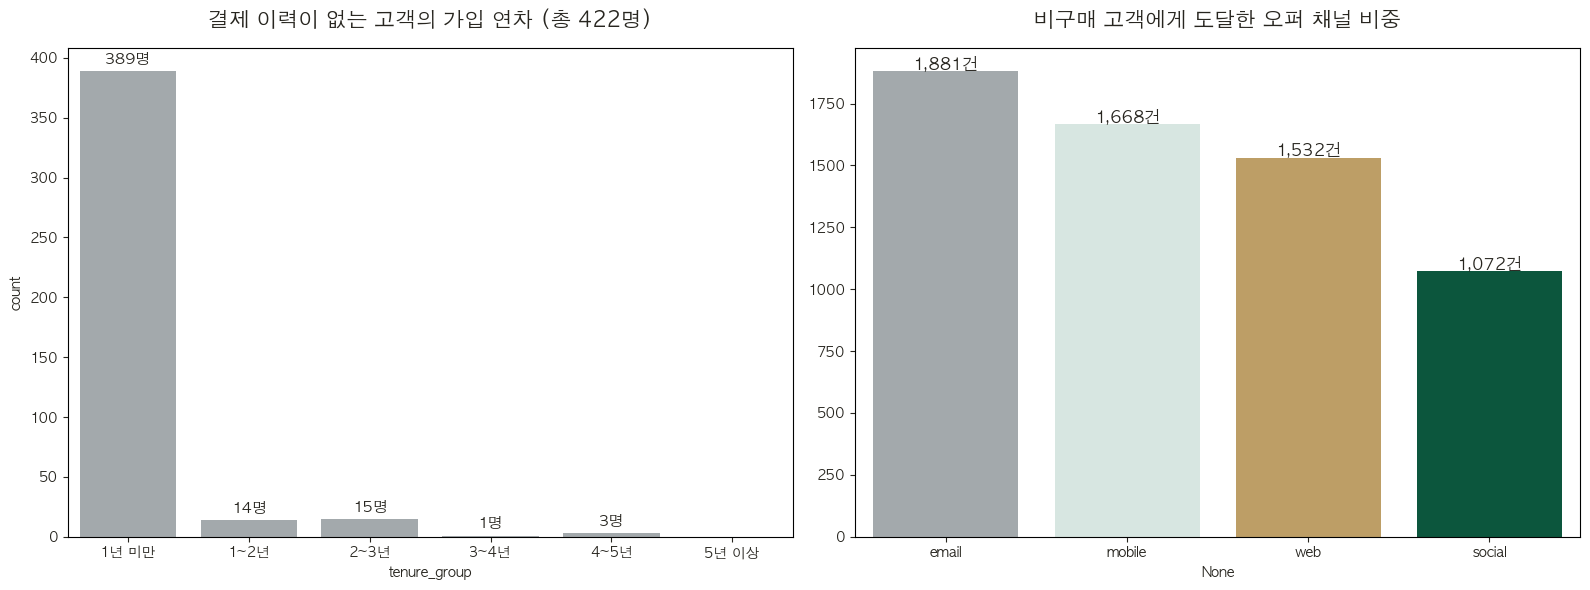

In [21]:
zero_spend_cust = customers[customers['spending_tier'] == '비구매']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 비구매 고객 가입 연차
ax1 = sns.countplot(data=zero_spend_cust, x='tenure_group', color=SB_GREY,
                    order=TENURE_ORDER, ax=axes[0])
axes[0].set_title(f'결제 이력이 없는 고객의 가입 연차 (총 {len(zero_spend_cust):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 비구매 고객 도달 채널
zero_spend_ids = zero_spend_cust['customer_id']
zero_channels  = (
    df[(df['customer_id'].isin(zero_spend_ids)) & (df['event'] == 'received')]
    [['email', 'mobile', 'web', 'social']]
    .sum()
    .sort_values(ascending=False)
)
ax2 = sns.barplot(x=zero_channels.index, y=zero_channels.values,
                  palette=[SB_GREY, SB_LIGHT_GREEN, SB_GOLD, SB_GREEN], ax=axes[1])
axes[1].set_title('비구매 고객에게 도달한 오퍼 채널 비중',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(zero_channels.values):
    ax2.text(i, v + 5, f'{v:,.0f}건', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

#### [액션 플랜]
##### 1년 미만 신규 고객 → 첫 구매 BOGO 쿠폰
##### 가입 기간 긴 미활성 고객 → 휴면 전환 안내(앱 푸시/이메일)
##### Unknown 그룹에는 프로모션 발송 비용(예: 알림톡, SMS 발송비)을 최소화하고, 무료 채널(앱 푸시, 이메일) 위주로만 운영하여 마케팅 ROI를 방어해야 한다.

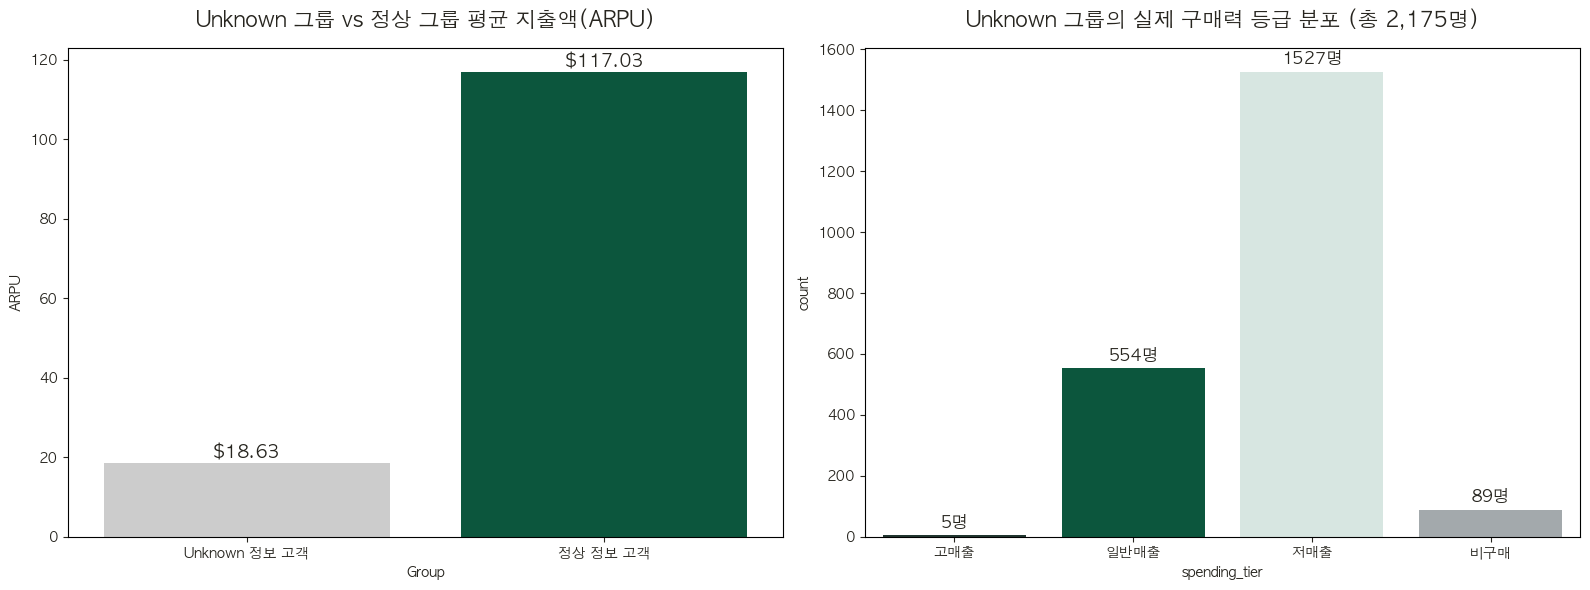

In [22]:
unknown_cust = customers[customers['income_group'] == 'Unknown']
known_cust   = customers[customers['income_group'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Unknown vs 정상 ARPU 비교
arpu_data = pd.DataFrame({
    'Group': ['Unknown 정보 고객', '정상 정보 고객'],
    'ARPU' : [unknown_cust['total_amount'].mean(), known_cust['total_amount'].mean()]
})
ax1 = sns.barplot(data=arpu_data, x='Group', y='ARPU',
                  palette=['#CCCCCC', SB_GREEN], ax=axes[0])
axes[0].set_title('Unknown 그룹 vs 정상 그룹 평균 지출액(ARPU)',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(arpu_data['ARPU']):
    ax1.text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

# 2. Unknown 그룹 구매력 등급 분포
ax2 = sns.countplot(data=unknown_cust, x='spending_tier',
                    palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, '#A2AAAD'],
                    order=['고매출', '일반매출', '저매출', '비구매'], ax=axes[1])
axes[1].set_title(f'Unknown 그룹의 실제 구매력 등급 분포 (총 {len(unknown_cust):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=12)

plt.tight_layout()
plt.show()


## 종합 인사이트 & 액션 플랜

| 세그먼트 | 오퍼 유형 | 핵심 채널 | 우선순위 |
|----------|-----------|-----------|----------|
| **VIP (상위 20%)** | 정보성 오퍼 (브랜드 상기) | Email / App Push | ★★★ |
| **잠재 VIP** (고소득·저지출 일반 고객) | 선호 오퍼 집중 타겟팅 (BOGO or Discount) | Mobile | ★★★ |
| **신규 비구매** (가입 1년 미만) | 첫 구매 BOGO 파격 쿠폰 | Mobile / Social | ★★ |
| **장기 비구매** (가입 2년 이상, 결제 없음) | 휴면 전환 안내 또는 윈백 할인 | Email | ★ |
| **Unknown 소득 고매출** | 정보성 오퍼 (Privacy 존중) | App Push | ★★ |

#### 높은 전환율이 보장되는 90K 이상 우량 고객은 할인보다 브랜드 경험 중심의 프리미엄화 전략을 취하고,

#### 성장의 핵심 키를 쥔 5060 잠재 VIP에게는 가장 반응이 좋은 BOGO 오퍼로 활성화를 유도하며,

#### Unknown 및 미결제 그룹에 낭비되던 마케팅 비용은 최소화해야 합니다.

### 주요 수치 요약
- 상위 20% VIP가 전체 매출의 약 54% 기여
- 정보성 오퍼 조회 고객의 일반 결제 횟수 유의미하게 높음 (Mann-Whitney p<0.05 확인 완료)
- 소득 구간별 지출액은 유의미한 차이가 있다 (Kruskal-Wallis 검정 결과 p=0.0001)

> **한계**: 전체 분석 기간이 약 30일로 짧아 장기 고객 행동 패턴이 과소 추정될 수 있습니다.
> 후광 효과 분석은 상관관계이며, 인과 관계로 단정하려면 A/B 테스트가 필요합니다.